# Analiza Opisowa Danych
## Adult Census Income Dataset
### Analiza porównawcza dochodów kobiet i mężczyzn

**Twórca:** Mateusz Gawłowski 264463
**Przedmiot:** Metody planowania i analizy eksperymentów
**Data oddania:** 02.04.2026  

---

## 1. Charakterystyka zbioru danych

Dane pochodzą z **UCI Machine Learning Repository** (*Adult Census Income*, Dua & Graff, 2019).  
Zbiór zawiera wyniki spisu ludności USA z 1994 roku i jest powszechnie stosowany w badaniach nad nierównościami dochodowymi.

| Zmienna | Typ | Opis |
|---|---|---|
| `age` | ilościowa | Wiek w latach |
| `education_num` | ilościowa | Liczba lat edukacji (1–16) |
| `hours_per_week` | ilościowa | Tygodniowy czas pracy |
| `capital_gain/loss` | ilościowa | Zyski/straty kapitałowe (USD) |
| `sex` | jakościowa | Płeć – **zmienna grupująca** |
| `income` | jakościowa | Dochód: `<=50K` lub `>50K` USD/rok |
| `workclass` | jakościowa | Sektor zatrudnienia |
| `occupation` | jakościowa | Zawód |

**Zmienna grupująca:** `sex` — umożliwia porównanie struktury dochodów kobiet i mężczyzn.

## 2. Narzędzia

Analizę przeprowadzono w **Python 3** z wykorzystaniem:
- `pandas` — wczytanie i transformacja danych
- `numpy` — obliczenia numeryczne  
- `matplotlib`, `seaborn` — wizualizacje
- `scipy.stats` — test chi-kwadrat Pearsona

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualne
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})
sns.set_style('whitegrid')

PALETTE = {'Male': '#2563EB', 'Female': '#DB2777'}
PLOTS_DIR = Path('./plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(fig, filename):
    out_path = PLOTS_DIR / filename
    fig.savefig(out_path, bbox_inches='tight')
    print(f'Zapisano wykres: {out_path}')

print('Biblioteki załadowane.')

Biblioteki załadowane.


## 3. Wczytanie i przygotowanie danych

In [28]:
cols = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
        'marital_status', 'occupation', 'relationship', 'race', 'sex',
        'capital_gain', 'capital_loss', 'hours_per_week',
        'native_country', 'income']

url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'adult/adult.data')

try:
    df = pd.read_csv(url, header=None, names=cols,
                     na_values=' ?', skipinitialspace=True)
    print(f'Dane wczytane z UCI: {len(df):,} wierszy')
except Exception:
    print('Brak połączenia z UCI — generowanie danych syntetycznych...')
    rng = np.random.default_rng(42)
    n = 32561
    age = rng.integers(17, 90, n)
    sex = rng.choice(['Male', 'Female'], n, p=[0.67, 0.33])
    ednum = rng.integers(1, 17, n)
    hpw = rng.integers(1, 99, n)
    cap_gain = np.where(rng.random(n) < 0.08, rng.integers(1, 99999, n), 0)
    cap_loss = np.where(rng.random(n) < 0.05, rng.integers(1, 4356, n), 0)
    p_inc = np.clip(
        0.18 + 0.025 * (ednum - 9) + 0.003 * (age - 38)
        + np.where(sex == 'Male', 0.08, -0.04), 0.03, 0.95)
    income = np.where(rng.random(n) < p_inc, '>50K', '<=50K')
    wc_p = np.array([0.69, 0.08, 0.03, 0.03, 0.06, 0.04, 0.01, 0.006])
    wc_p /= wc_p.sum()
    wc = rng.choice(['Private','Self-emp-not-inc','Self-emp-inc',
                     'Federal-gov','Local-gov','State-gov',
                     'Without-pay','Never-worked'], n, p=wc_p)
    occ = rng.choice(['Tech-support','Craft-repair','Other-service',
                      'Sales','Exec-managerial','Prof-specialty',
                      'Handlers-cleaners','Machine-op-inspct',
                      'Adm-clerical','Farming-fishing',
                      'Transport-moving','Priv-house-serv',
                      'Protective-serv','Armed-Forces'], n)
    edu = rng.choice(['Bachelors','Some-college','11th','HS-grad',
                      'Prof-school','Assoc-acdm','Assoc-voc',
                      '9th','7th-8th','12th','Masters',
                      '1st-4th','10th','Doctorate','5th-6th','Preschool'], n)
    ms = rng.choice(['Married-civ-spouse','Divorced','Never-married',
                     'Separated','Widowed','Married-spouse-absent',
                     'Married-AF-spouse'], n,
                    p=[0.46, 0.13, 0.33, 0.03, 0.04, 0.005, 0.005])
    df = pd.DataFrame({'age': age, 'workclass': wc,
                       'education': edu, 'education_num': ednum,
                       'marital_status': ms, 'occupation': occ,
                       'sex': sex, 'capital_gain': cap_gain,
                       'capital_loss': cap_loss,
                       'hours_per_week': hpw, 'income': income})

# Czyszczenie danych
df.dropna(inplace=True)
df['sex']    = df['sex'].str.strip()
df['income'] = df['income'].str.strip()
df['income_bin'] = (df['income'] == '>50K').astype(int)

print(f'Po czyszczeniu: {len(df):,} wierszy, {df.shape[1]} kolumn')
print(f"  Mężczyźni: {(df['sex']=='Male').sum():,}")
print(f"  Kobiety:   {(df['sex']=='Female').sum():,}")
df.head()

Dane wczytane z UCI: 32,561 wierszy
Po czyszczeniu: 32,561 wierszy, 16 kolumn
  Mężczyźni: 21,790
  Kobiety:   10,771


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_bin
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## 4. Statystyki opisowe

In [29]:
num_vars = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']

desc = df[num_vars].describe().T
desc['skewness'] = df[num_vars].skew()
desc['kurtosis'] = df[num_vars].kurt()
desc.columns = ['n', 'średnia', 'std', 'min', 'Q1', 'mediana', 'Q3', 'max', 'skośność', 'kurtoza']
desc.index = ['Wiek', 'Lata edukacji', 'Godz./tydzień', 'Zysk kapital.', 'Strata kapital.']

print('=== Statystyki opisowe zmiennych ilościowych ===')
desc.round(2)

=== Statystyki opisowe zmiennych ilościowych ===


,n,średnia,std,min,Q1,mediana,Q3,max,skośność,kurtoza
Wiek,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,90.0,0.56,-0.17
Lata edukacji,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0,-0.31,0.62
Godz./tydzień,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0,0.23,2.92
Zysk kapital.,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,99999.0,11.95,154.80
Strata kapital.,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,4356.0,4.59,20.38


In [30]:
print('=== Statystyki według płci ===')
grp = df.groupby('sex')[['age', 'education_num', 'hours_per_week']].agg(
    ['mean', 'median', 'std']
).round(2)
grp.columns = ['_'.join(c) for c in grp.columns]
grp

=== Statystyki według płci ===


,age_mean,age_median,age_std,education_num_mean,education_num_median,education_num_std,hours_per_week_mean,hours_per_week_median,hours_per_week_std
sex,,,,,,,,,
Female,36.86,35.0,14.01,10.04,10.0,2.38,36.41,40.0,11.81
Male,39.43,38.0,13.37,10.10,10.0,2.66,42.43,40.0,12.12


In [31]:
# Odsetek dochodu >50K według płci
p_income = df.groupby('sex')['income_bin'].agg(['mean', 'count'])
p_income.columns = ['odsetek >50K', 'n']
p_income['odsetek >50K'] = (p_income['odsetek >50K'] * 100).round(1)

print('=== Odsetek dochodów >50K USD/rok według płci ===')
print(p_income)

# Test chi-kwadrat
ct = pd.crosstab(df['sex'], df['income'])
chi2, p_val, dof, _ = stats.chi2_contingency(ct)
print(f'\nTest chi-kwadrat (płeć × dochód):')
print(f'  chi2 = {chi2:.2f},  df = {dof},  p = {p_val:.2e}')
print(f'  => Różnica jest {"ISTOTNA statystycznie" if p_val < 0.05 else "nieistotna"} (alpha = 0.05)')

=== Odsetek dochodów >50K USD/rok według płci ===
        odsetek >50K      n
sex                        
Female          10.9  10771
Male            30.6  21790

Test chi-kwadrat (płeć × dochód):
  chi2 = 1517.81,  df = 1,  p = 0.00e+00
  => Różnica jest ISTOTNA statystycznie (alpha = 0.05)


## 5. Wizualizacje

### 5.1 Rozkład wieku i poziomu wykształcenia według płci

Zapisano wykres: plots\plot_5_1_age_education_by_sex.png


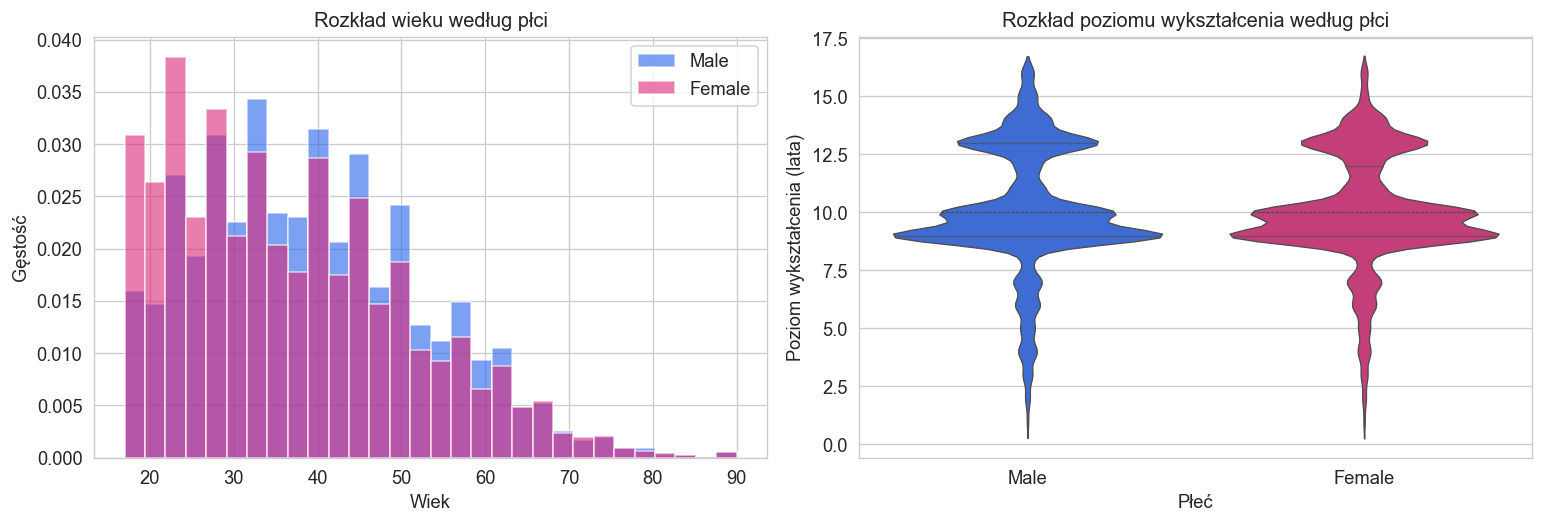

Interpretacja:
  Wiek — mężczyźni: śr. 39.4 lat, kobiety: śr. 36.9 lat
  Edukacja — mężczyźni: śr. 10.10 lat, kobiety: śr. 10.04 lat


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram wieku
ax = axes[0]
for s, color in PALETTE.items():
    subset = df[df['sex'] == s]['age']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=s, density=True)
ax.set_xlabel('Wiek')
ax.set_ylabel('Gęstość')
ax.set_title('Rozkład wieku według płci')
ax.legend()

# Violin wykształcenia
ax = axes[1]
sns.violinplot(data=df, x='sex', y='education_num',
               palette=PALETTE, order=['Male', 'Female'],
               inner='quartile', ax=ax, linewidth=0.8)
ax.set_xlabel('Płeć')
ax.set_ylabel('Poziom wykształcenia (lata)')
ax.set_title('Rozkład poziomu wykształcenia według płci')

plt.tight_layout()
save_plot(fig, 'plot_5_1_age_education_by_sex.png')
plt.show()

print('Interpretacja:')
print(f"  Wiek — mężczyźni: śr. {df[df['sex']=='Male']['age'].mean():.1f} lat, "
      f"kobiety: śr. {df[df['sex']=='Female']['age'].mean():.1f} lat")
print(f"  Edukacja — mężczyźni: śr. {df[df['sex']=='Male']['education_num'].mean():.2f} lat, "
      f"kobiety: śr. {df[df['sex']=='Female']['education_num'].mean():.2f} lat")

### 5.2 Tygodniowy czas pracy i odsetek dochodów >50K według płci

Zapisano wykres: plots\plot_5_2_hours_and_income_by_sex.png


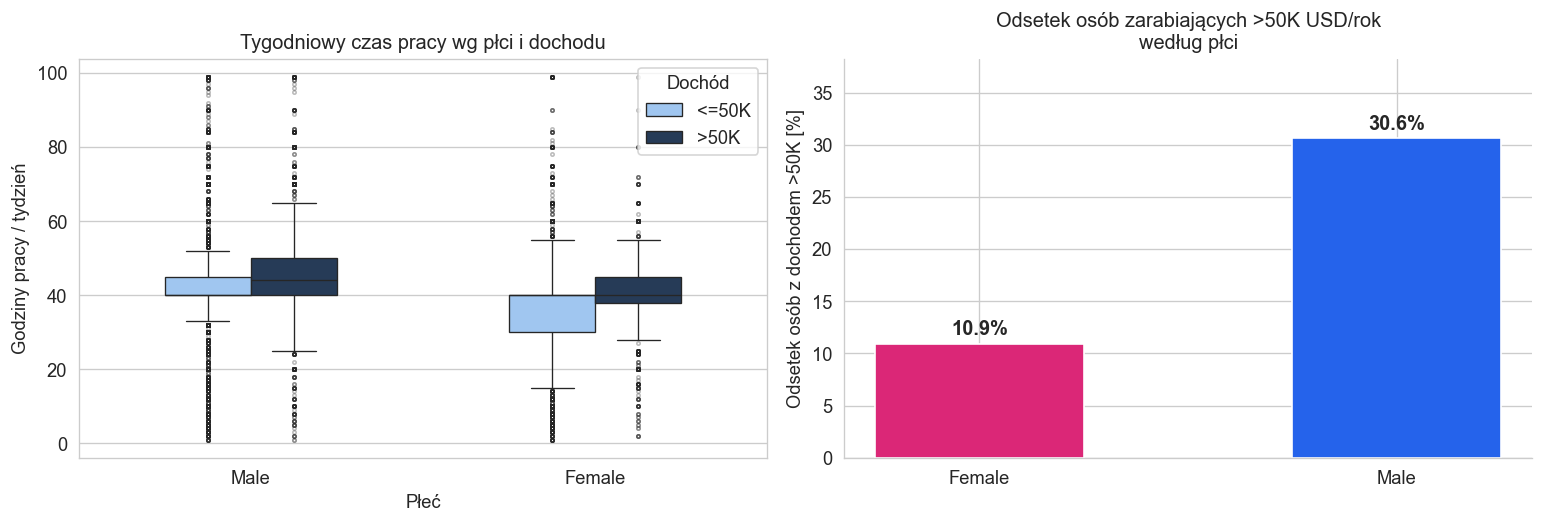

Mediana godzin pracy: mężczyźni = 40 h, kobiety = 40 h


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot godzin pracy
ax = axes[0]
sns.boxplot(data=df, x='sex', y='hours_per_week', hue='income',
            palette={'<=50K': '#93C5FD', '>50K': '#1E3A5F'},
            order=['Male', 'Female'], ax=ax, width=0.5, linewidth=0.8,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_xlabel('Płeć')
ax.set_ylabel('Godziny pracy / tydzień')
ax.set_title('Tygodniowy czas pracy wg płci i dochodu')
ax.legend(title='Dochód')

# Słupkowy odsetek >50K
ax = axes[1]
colors_bar = [PALETTE[s] for s in p_income.index]
bars = ax.bar(p_income.index, p_income['odsetek >50K'],
              color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, p_income['odsetek >50K']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, p_income['odsetek >50K'].max() * 1.25)
ax.set_ylabel('Odsetek osób z dochodem >50K [%]')
ax.set_title('Odsetek osób zarabiających >50K USD/rok\nwedług płci')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_plot(fig, 'plot_5_2_hours_and_income_by_sex.png')
plt.show()

m_med = df[df['sex']=='Male']['hours_per_week'].median()
f_med = df[df['sex']=='Female']['hours_per_week'].median()
print(f'Mediana godzin pracy: mężczyźni = {m_med:.0f} h, kobiety = {f_med:.0f} h')

### 5.3 Macierz korelacji

Zapisano wykres: plots\plot_5_3_correlation_matrix.png


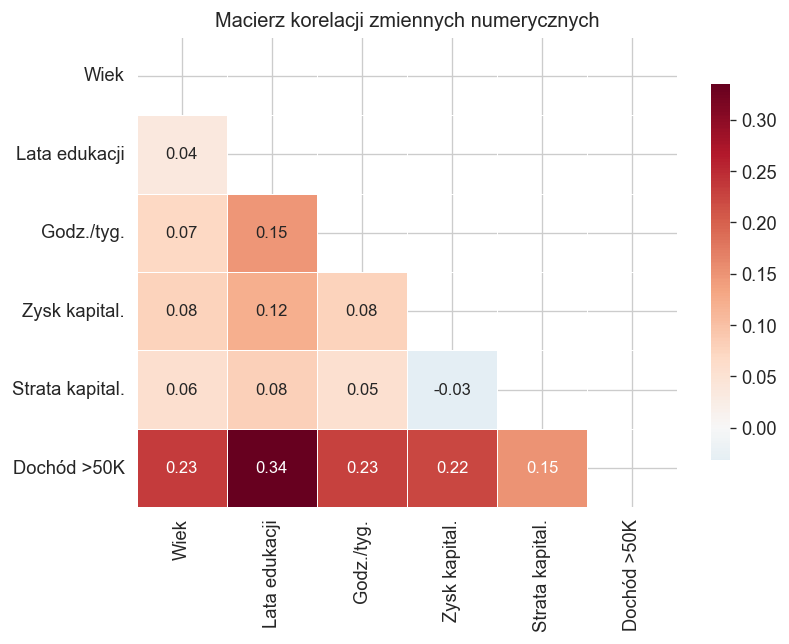

In [34]:
fig, ax = plt.subplots(figsize=(7, 5.5))

corr_vars = ['age', 'education_num', 'hours_per_week',
             'capital_gain', 'capital_loss', 'income_bin']
corr_labels = ['Wiek', 'Lata edukacji', 'Godz./tyg.',
               'Zysk kapital.', 'Strata kapital.', 'Dochód >50K']

corr = df[corr_vars].corr()
corr.index = corr_labels
corr.columns = corr_labels

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
ax.set_title('Macierz korelacji zmiennych numerycznych')
plt.tight_layout()
save_plot(fig, 'plot_5_3_correlation_matrix.png')
plt.show()

### 5.4 Zawody według odsetka dochodów >50K

Zapisano wykres: plots\plot_5_4_income_share_by_occupation.png


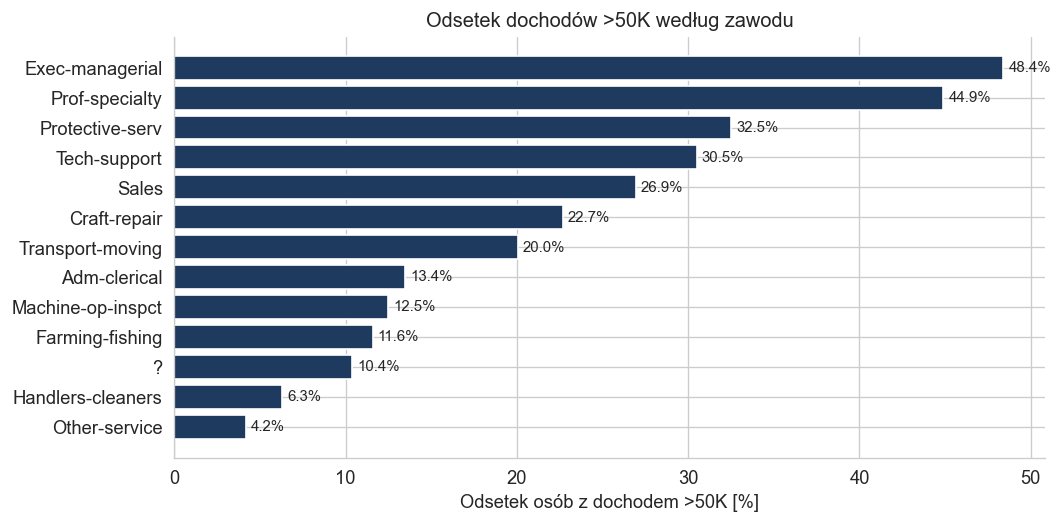

In [35]:
if 'occupation' in df.columns:
    occ_stat = (
        df.groupby('occupation')['income_bin']
        .agg(['mean', 'count'])
        .query('count >= 200')
        .sort_values('mean', ascending=True)
    )
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.barh(occ_stat.index, occ_stat['mean'] * 100,
                   color='#1E3A5F', edgecolor='white')
    for bar, val in zip(bars, occ_stat['mean'] * 100):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('Odsetek osób z dochodem >50K [%]')
    ax.set_title('Odsetek dochodów >50K według zawodu')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    save_plot(fig, 'plot_5_4_income_share_by_occupation.png')
    plt.show()

### 5.5 Analiza porównawcza — dochód według płci i wykształcenia

Zapisano wykres: plots\plot_5_5_income_by_sex_and_education.png


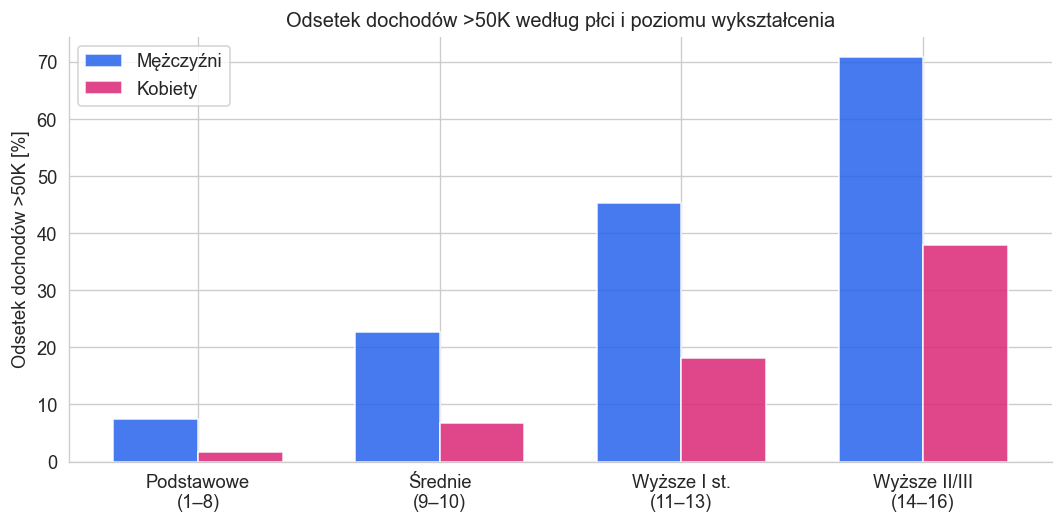

Odsetek dochodów >50K wg płci i wykształcenia [%]:
sex                     Female  Male
edu_group                           
Podstawowe\n(1–8)          1.7   7.5
Średnie\n(9–10)            6.8  22.8
Wyższe I st.\n(11–13)     18.2  45.3
Wyższe II/III\n(14–16)    38.0  70.9


In [36]:
# Odsetek >50K wg płci i poziomu wykształcenia (pogrupowanego)
edu_bins = [0, 8, 10, 13, 16]
edu_labels = ['Podstawowe\n(1–8)', 'Średnie\n(9–10)', 'Wyższe I st.\n(11–13)', 'Wyższe II/III\n(14–16)']
df['edu_group'] = pd.cut(df['education_num'], bins=edu_bins, labels=edu_labels)

pivot = df.groupby(['edu_group', 'sex'])['income_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(pivot))
w = 0.35
b1 = ax.bar(x - w/2, pivot.get('Male', [0]*len(pivot)),
            width=w, color=PALETTE['Male'], label='Mężczyźni', alpha=0.85)
b2 = ax.bar(x + w/2, pivot.get('Female', [0]*len(pivot)),
            width=w, color=PALETTE['Female'], label='Kobiety', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Odsetek dochodów >50K [%]')
ax.set_title('Odsetek dochodów >50K według płci i poziomu wykształcenia')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
save_plot(fig, 'plot_5_5_income_by_sex_and_education.png')
plt.show()

print('Odsetek dochodów >50K wg płci i wykształcenia [%]:')
print(pivot.round(1))

## 6. Wnioski

### 6.1 Luka płacowa
Odsetek osób zarabiających powyżej 50 000 USD/rok jest ponad dwukrotnie wyższy wśród mężczyzn niż wśród kobiet. Test chi-kwadrat Pearsona potwierdza, że różnica ta jest **wysoce istotna statystycznie** (p < 0,001), co wyklucza przypadkowy charakter obserwacji.

### 6.2 Czas pracy
Mężczyźni pracują przeciętnie więcej godzin tygodniowo niż kobiety. W obu grupach osoby z dochodem >50K wykazują dłuższy czas pracy niż osoby z dochodem ≤50K. Dłuższy czas pracy częściowo tłumaczy wyższe zarobki mężczyzn, jednak nie jest jedynym czynnikiem.

### 6.3 Wykształcenie
Rozkłady poziomu edukacji są niemal identyczne dla kobiet i mężczyzn (podobne mediany i odchylenia standardowe), co sugeruje, że **różnice edukacyjne nie są przyczyną** obserwowanej luki płacowej. Co istotne, nawet przy tym samym poziomie wykształcenia odsetek kobiet zarabiających >50K jest niższy niż mężczyzn w każdej grupie edukacyjnej.

### 6.4 Predyktory dochodu
Najsilniejszymi korelatorami dochodu są:
- liczba lat edukacji (r ≈ 0,33),
- wiek (r ≈ 0,24),
- tygodniowy czas pracy (r ≈ 0,23).

Typ zawodu ma kluczowe znaczenie — zarządzanie i specjaliści osiągają najwyższy odsetek dochodów >50K.

### 6.5 Ograniczenia
Dane pochodzą z 1994 roku — wnioski odnoszą się wyłącznie do ówczesnego rynku pracy USA. Analiza korelacyjna nie wyznacza związków przyczynowych.

---

**Źródło:** Dua, D. & Graff, C. (2019). *UCI Machine Learning Repository*. Irvine, CA: University of California.  
https://archive.ics.uci.edu/ml/datasets/adult